# Data Pre-processing
---


In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

fake_df = pd.read_csv('/content/drive/MyDrive//DATA6505_Group2/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/DATA6505_Group2/True.csv')

Mounted at /content/drive


In [ ]:
# New Column "Label" for fake/real news
# 0 = Real and 1 = Fake
fake_df['label'] = 1
true_df['label'] = 0
df = pd.concat([fake_df, true_df], ignore_index=True)

In [ ]:
# Merge fake and real datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

In [ ]:
#Date Parsing

from dateutil.parser import parse

def smart_parse(x):
    try:
        return parse(str(x), fuzzy=True)
    except:
        return None

df['date'] = df['date'].apply(smart_parse)
df = df.dropna(subset=['date'])


In [ ]:
# Remove NULL Values
df.dropna(subset=['text', 'title', 'subject'], inplace=True)

In [ ]:
# Remove Duplicates
df.drop_duplicates(subset=['text'], inplace=True)

print(f"Total rows after unification and date parsing: {len(df)}")

Total rows after unification and date parsing: 38640


In [ ]:
# Download NLTK Data
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Function to expand contractions
def expand_contractions(text):
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

In [ ]:
# List of English stopwords
stop_words = set(stopwords.words('english'))

def normalize_text(text):
    # Expand contractions
    text = expand_contractions(text)

    # Lowercase conversion
    text = text.lower()

    # Punctuation Removal
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Stopword Removal
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

In [ ]:
# Advanced NLP Steps

def advanced_nlp_steps(text):
  if text is None or pd.isna(text) or text == "":
        return ""

  # Tokenization
  words = word_tokenize(text)

  # Lemmatization
  words = [lemmatizer.lemmatize(word) for word in words]

  # Rejoin the words into a new string
  text = ' '.join(words)

  return text

In [ ]:
# Apply normalization to text column
df['cleaned_text'] = df['text'].apply(normalize_text)

print("Text normalization complete. New column 'cleaned_text created.")

# Apply advanced NLP steps
df['final_text'] = df['cleaned_text'].apply(advanced_nlp_steps)

print("Advanced NLP steps complete. New column 'final_text' created.")

Text normalization complete. New column 'cleaned_text created.
Advanced NLP steps complete. New column 'final_text' created.


In [ ]:
# Date formatting
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['year_month'] = df['date'].dt.to_period('M')

print("Date formatting complete. New columns 'year', 'month', 'day', 'year_month' created.")

Date formatting complete. New columns 'year', 'month', 'day', 'year_month' created.


In [ ]:
# Inspect df
df.head()

,title,text,subject,date,label,cleaned_text,final_text,year,month,day,year_month
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31,1,donald trump wish americans happy new year lea...,donald trump wish american happy new year leav...,2017,12,31,2017-12
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31,1,house intelligence committee chairman devin nu...,house intelligence committee chairman devin nu...,2017,12,31,2017-12
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30,1,friday revealed former milwaukee sheriff david...,friday revealed former milwaukee sheriff david...,2017,12,30,2017-12
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29,1,christmas day donald trump announced would bac...,christmas day donald trump announced would bac...,2017,12,29,2017-12
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25,1,pope francis used annual christmas day message...,pope francis used annual christmas day message...,2017,12,25,2017-12


# Exploratory Data Analysis
---


**Subject Distribution**

In [ ]:
# Separate Real and Fake news
real_df = df[df['label'] == 0]
fake_df = df[df['label'] == 1]

# Count subjects
real_subject_counts = real_df['subject'].value_counts().reset_index()
fake_subject_counts = fake_df['subject'].value_counts().reset_index()

real_subject_counts.columns = ['Subject', 'Real_Count']
fake_subject_counts.columns = ['Subject', 'Fake_Count']

print("Real News Subject Distribution:")
print(real_subject_counts)

print("\nFake News Subject Distribution:")
print(fake_subject_counts)


Real News Subject Distribution:
        Subject  Real_Count
0  politicsNews       11213
1     worldnews        9978

Fake News Subject Distribution:
           Subject  Fake_Count
0             News        9050
1         politics        6420
2          US_News         783
3        left-news         682
4  Government News         514


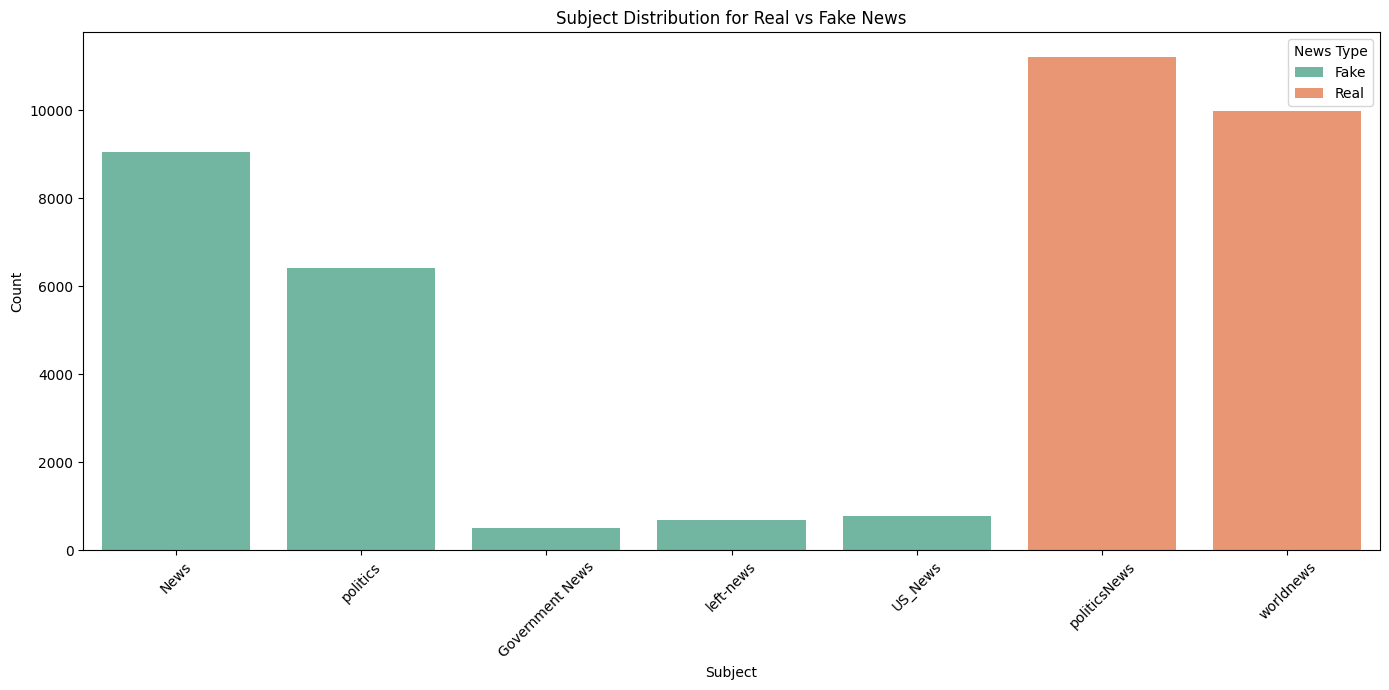

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
subject_plot = df.copy()
subject_plot['label'] = subject_plot['label'].map({0: 'Real', 1: 'Fake'})

sns.countplot(data=subject_plot, x='subject', hue='label', palette='Set2')
plt.title("Subject Distribution for Real vs Fake News")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='News Type')
plt.tight_layout()
plt.show()


**Unified Subject Categories**

In [ ]:
def map_subject_final(sub):
    sub = str(sub).lower()

    # Political news (fake + real)
    if "politics" in sub or "political" in sub:
        return "Political News"

    # Government news (fake + real)
    if "government" in sub or "gov" in sub:
        return "Government News"

    # World news
    if "world" in sub or "international" in sub or "global" in sub:
        return "World News"

    # US news
    if "us" in sub or "u.s." in sub or "america" in sub:
        return "US News"

    # Business & economy
    if "business" in sub or "economy" in sub or "finance" in sub:
        return "Business"

    # Tech & science
    if "tech" in sub or "technology" in sub or "science" in sub:
        return "Tech News"

    # If nothing matched
    return "Other"

# Apply mapping
df["unified_subject"] = df["subject"].apply(map_subject_final)
df["news_type"] = df["label"].map({0: "Real", 1: "Fake"})



In [ ]:
# Count per category
table = df.groupby(["unified_subject", "news_type"]).size().unstack(fill_value=0)

# Add totals
table["Total"] = table.sum(axis=1)

# Add percentages
table["% Real"] = (table["Real"] / table["Total"] * 100).round(1)
table["% Fake"] = (table["Fake"] / table["Total"] * 100).round(1)

# Reorder rows to match your screenshot
order = [
    "Political News",
    "World News",
    "US News",
    "Government News",
    "Business",
    "Tech News",
    "Other"
]

table = table.reindex(order, fill_value=0)

table


news_type,Fake,Real,Total,% Real,% Fake
unified_subject,,,,,
Political News,6420,11213,17633,63.6,36.4
World News,0,9978,9978,100.0,0.0
US News,783,0,783,0.0,100.0
Government News,514,0,514,0.0,100.0
Business,0,0,0,0.0,0.0
Tech News,0,0,0,0.0,0.0
Other,9732,0,9732,0.0,100.0


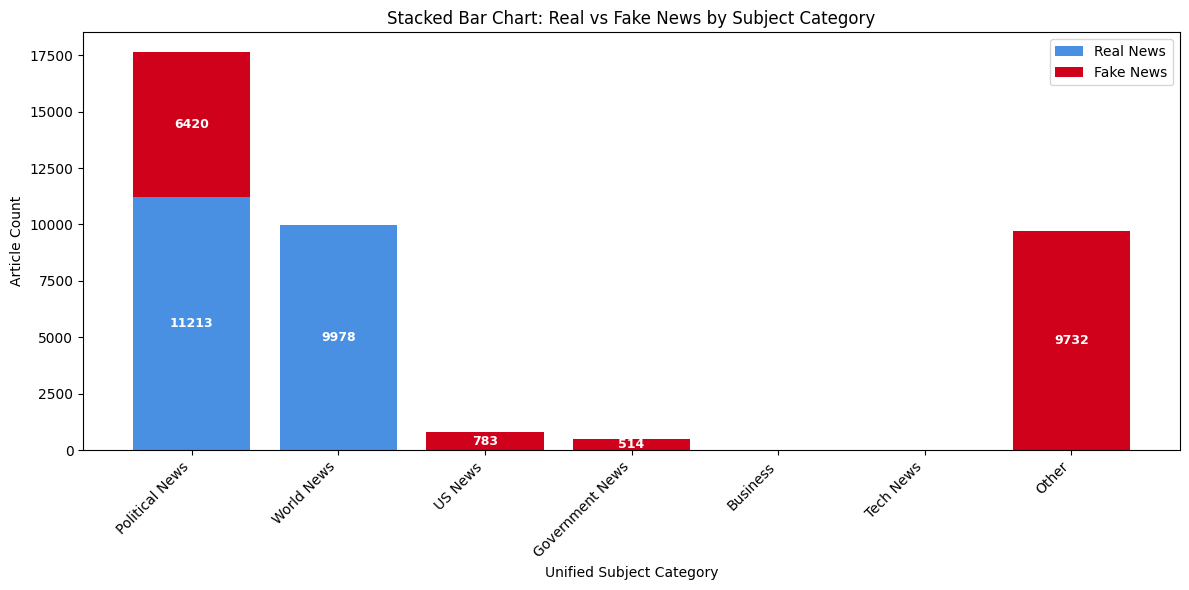

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the final subject distribution table you generated
plot_table = table.copy()

# Extract values
categories = plot_table.index.tolist()
real_counts = plot_table["Real"].tolist()
fake_counts = plot_table["Fake"].tolist()

# Position of bars on x-axis
x = np.arange(len(categories))

plt.figure(figsize=(12, 6))

# Plot Real News
plt.bar(x, real_counts, label="Real News", color="#4A90E2")

# Plot Fake News on top (stacked)
plt.bar(x, fake_counts, bottom=real_counts, label="Fake News", color="#D0021B")

# Labels
plt.title("Stacked Bar Chart: Real vs Fake News by Subject Category")
plt.xlabel("Unified Subject Category")
plt.ylabel("Article Count")
plt.xticks(x, categories, rotation=45, ha="right")

# Add labels on each segment
for i in range(len(categories)):
    # Real Label
    if real_counts[i] > 0:
        plt.text(i, real_counts[i] / 2, str(real_counts[i]),
                 ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    # Fake Label
    if fake_counts[i] > 0:
        plt.text(i, real_counts[i] + fake_counts[i] / 2, str(fake_counts[i]),
                 ha='center', va='center', color='white', fontsize=9, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()


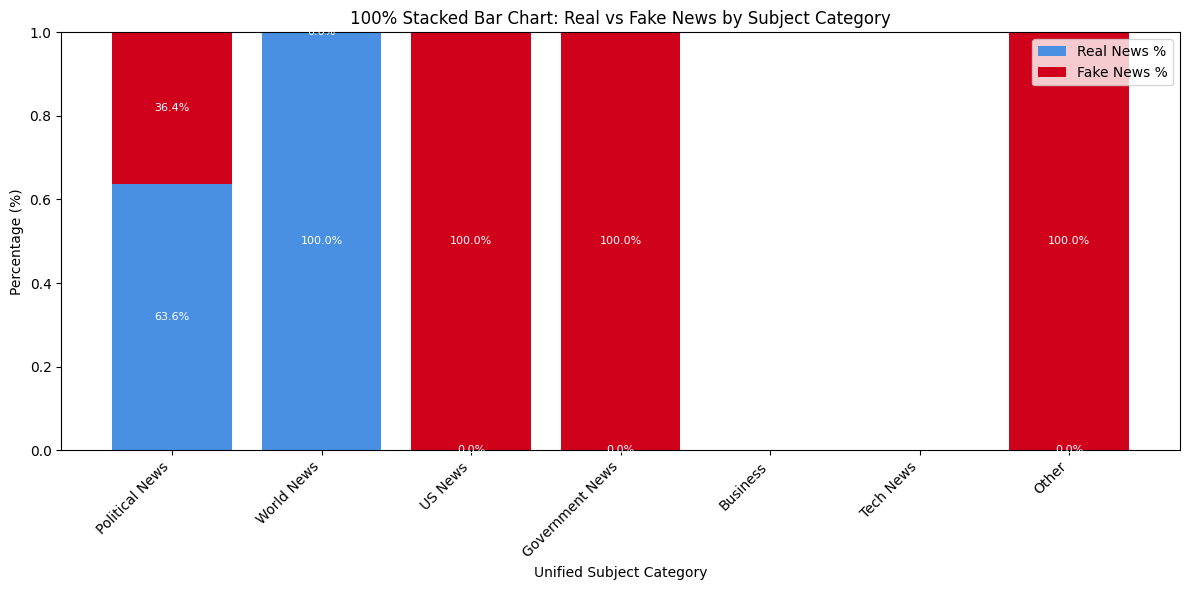

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use table generated earlier
plot_table = table.copy()

# Compute proportions
plot_table["Real %"] = plot_table["Real"] / plot_table["Total"]
plot_table["Fake %"] = plot_table["Fake"] / plot_table["Total"]

categories = plot_table.index.tolist()
real_pct = plot_table["Real %"].tolist()
fake_pct = plot_table["Fake %"].tolist()

x = np.arange(len(categories))

plt.figure(figsize=(12, 6))

# Plot Real % first
plt.bar(x, real_pct, label="Real News %", color="#4A90E2")

# Plot Fake % stacked on top
plt.bar(x, fake_pct, bottom=real_pct, label="Fake News %", color="#D0021B")

# Title & labels
plt.title("100% Stacked Bar Chart: Real vs Fake News by Subject Category")
plt.xlabel("Unified Subject Category")
plt.ylabel("Percentage (%)")
plt.xticks(x, categories, rotation=45, ha="right")

# Add percentage labels
for i in range(len(categories)):
    # Real %
    plt.text(i, real_pct[i] / 2,
             f"{real_pct[i]*100:.1f}%",
             ha="center", va="center", color="white", fontsize=8)

    # Fake %
    plt.text(i, real_pct[i] + fake_pct[i] / 2,
             f"{fake_pct[i]*100:.1f}%",
             ha="center", va="center", color="white", fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()


**Average Article Length by Subject**

In [ ]:
df['raw_length'] = df['text'].apply(lambda x: len(str(x).split()))

df[['text', 'raw_length']].head()


,text,raw_length
0,Donald Trump just couldn t wish all Americans ...,495
1,House Intelligence Committee Chairman Devin Nu...,305
2,"On Friday, it was revealed that former Milwauk...",580
3,"On Christmas day, Donald Trump announced that ...",444
4,Pope Francis used his annual Christmas Day mes...,420


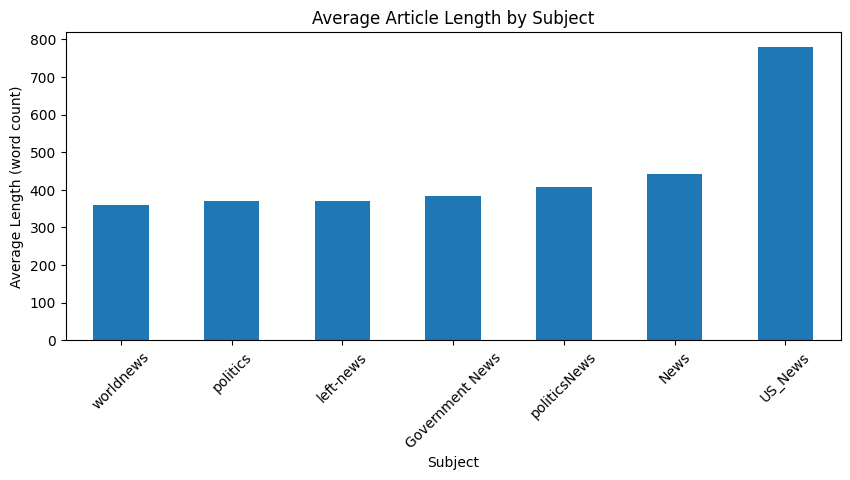

In [ ]:
avg_length_subject = df.groupby('subject')['raw_length'].mean()

avg_length_subject.sort_values().plot(kind='bar', figsize=(10,4))
plt.title("Average Article Length by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Length (word count)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Compute article length by word count
df["article_length"] = df["final_text"].astype(str).apply(lambda x: len(x.split()))


In [ ]:
avg_length = df.groupby("news_type")["article_length"].mean().reset_index()
avg_length


,news_type,article_length
0,Fake,234.776950
1,Real,230.869567


/tmp/ipython-input-3483241659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_length, x="news_type", y="article_length", palette=["#4A90E2", "#D0021B"])


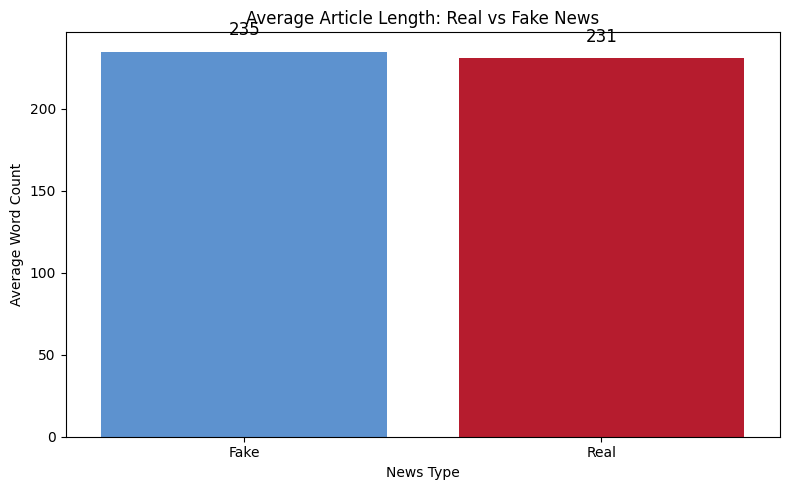

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=avg_length, x="news_type", y="article_length", palette=["#4A90E2", "#D0021B"])

# Add labels
for i, row in avg_length.iterrows():
    plt.text(i, row.article_length + 10, f"{row.article_length:.0f}",
             ha='center', fontsize=12)

plt.title("Average Article Length: Real vs Fake News")
plt.xlabel("News Type")
plt.ylabel("Average Word Count")
plt.tight_layout()
plt.show()


**Temporal Trend Analysis**

In [ ]:
# Filtering for Real News

real_df = df[df['label'] == 0].copy()
real_df['year_month'] = real_df['date'].dt.to_period('M')
real_df['year_month'] = real_df['year_month'].dt.to_timestamp()

#Counting Real news per month
real_trend = real_df.groupby('year_month').size().reset_index(name='Count')

print("Real News Monthly Counts:")
print(real_trend.head(30))


Real News Monthly Counts:
   year_month  Count
0  2016-01-01    244
1  2016-02-01    428
2  2016-03-01    489
3  2016-04-01    383
4  2016-05-01    394
5  2016-06-01    417
6  2016-07-01    337
7  2016-08-01    264
8  2016-09-01    350
9  2016-10-01    334
10 2016-11-01    635
11 2016-12-01    422
12 2017-01-01    750
13 2017-02-01    589
14 2017-03-01    678
15 2017-04-01    528
16 2017-05-01    504
17 2017-06-01    555
18 2017-07-01    538
19 2017-08-01    651
20 2017-09-01   3058
21 2017-10-01   3154
22 2017-11-01   3076
23 2017-12-01   2413


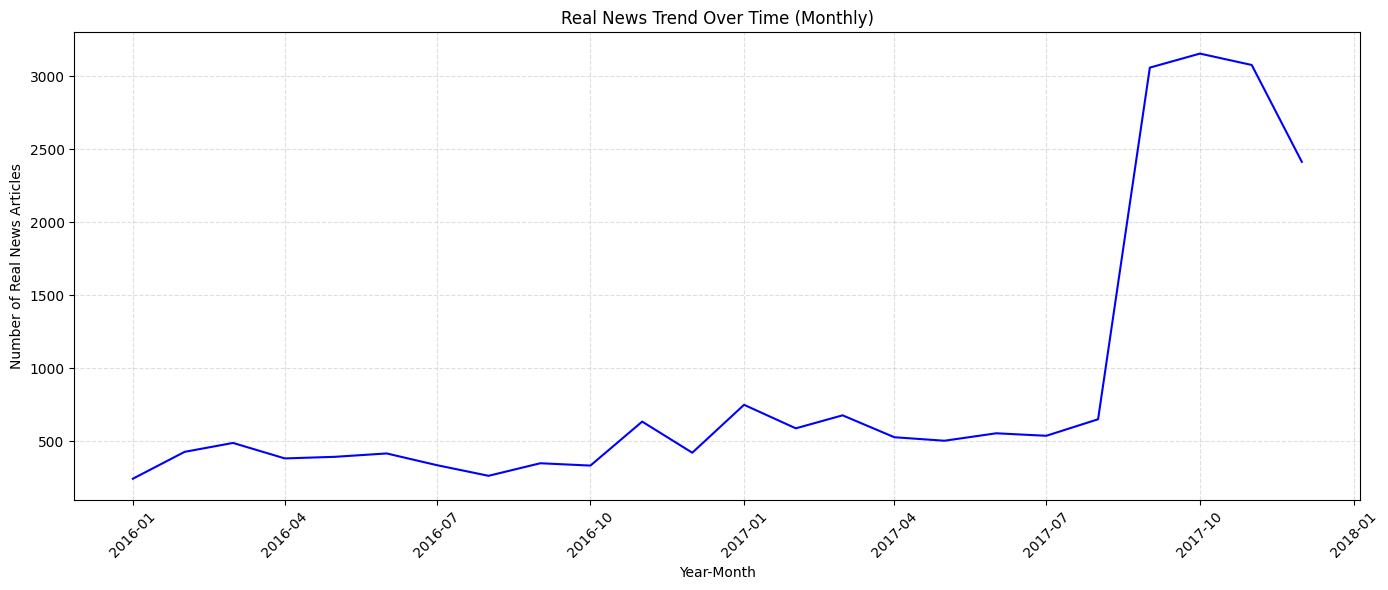

In [ ]:
#Trend of Real News
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.lineplot(data=real_trend, x='year_month', y='Count', color='blue')
plt.title("Real News Trend Over Time (Monthly)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Real News Articles")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
#Filtering Fake News
fake_df = df[df['label'] == 1].copy()
fake_df['year_month'] = fake_df['date'].dt.to_period('M')
fake_df['year_month'] = fake_df['year_month'].dt.to_timestamp()



In [ ]:
#Count of Fake News per month

fake_trend = fake_df.groupby('year_month').size().reset_index(name='Count')

print("Fake News Monthly Counts:")
print(fake_trend.head(40))


Fake News Monthly Counts:
   year_month  Count
0  2015-03-01      6
1  2015-04-01    151
2  2015-05-01    180
3  2015-06-01    140
4  2015-07-01    195
5  2015-08-01    179
6  2015-09-01    156
7  2015-10-01    204
8  2015-11-01    191
9  2015-12-01    195
10 2016-01-01    900
11 2016-02-01    872
12 2016-03-01    887
13 2016-04-01    818
14 2016-05-01    834
15 2016-06-01    694
16 2016-07-01    709
17 2016-08-01    711
18 2016-09-01    702
19 2016-10-01    764
20 2016-11-01    669
21 2016-12-01    655
22 2017-01-01    746
23 2017-02-01    645
24 2017-03-01    723
25 2017-04-01    589
26 2017-05-01    624
27 2017-06-01    619
28 2017-07-01    556
29 2017-08-01    556
30 2017-09-01    453
31 2017-10-01    418
32 2017-11-01    369
33 2017-12-01    304
34 2018-02-01     35


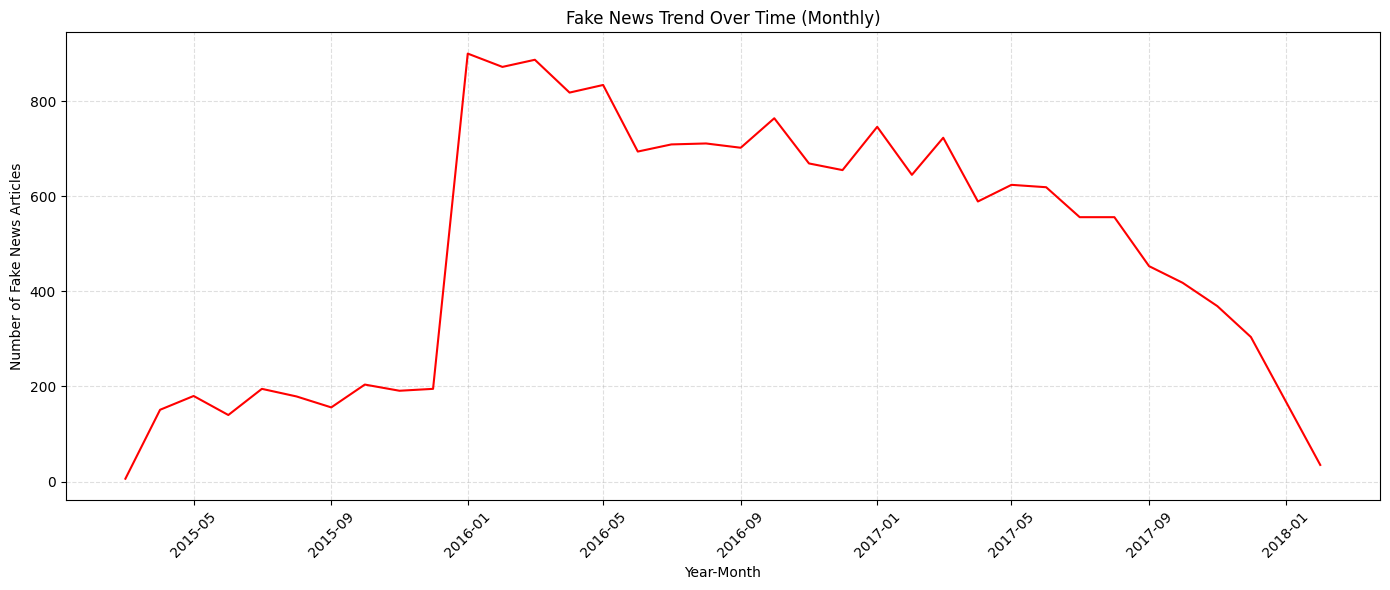

In [ ]:
#Trendline for Fake News

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.lineplot(data=fake_trend, x='year_month', y='Count', color='red')
plt.title("Fake News Trend Over Time (Monthly)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Fake News Articles")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


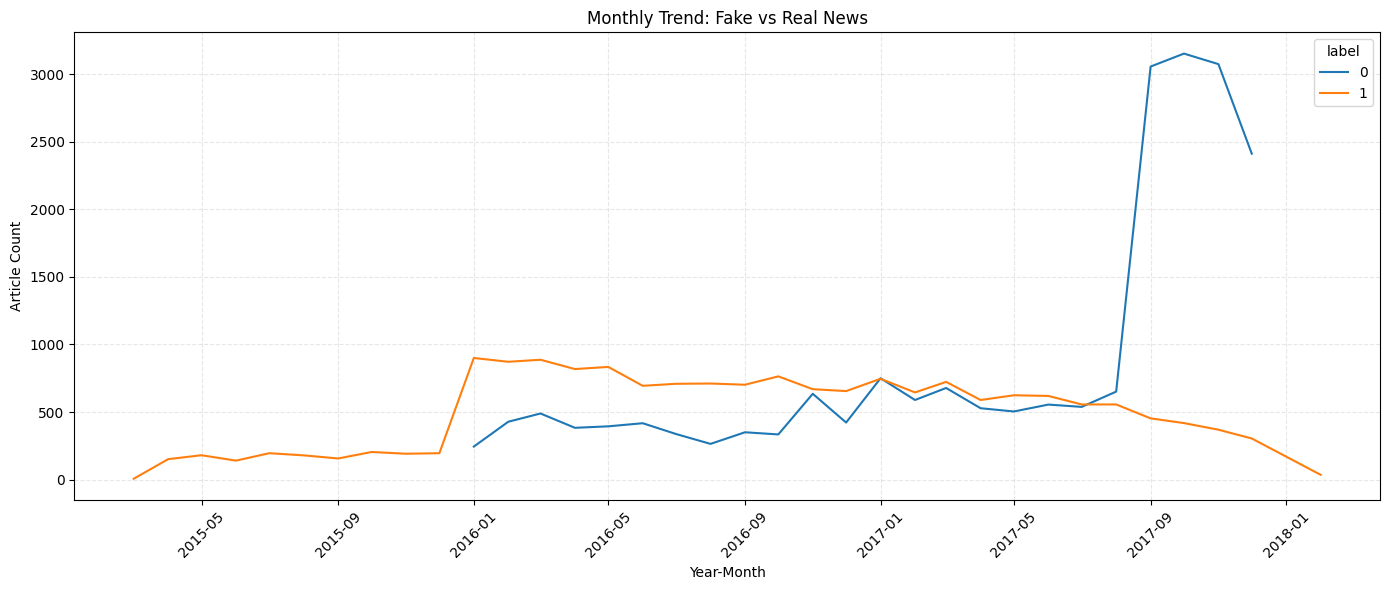

In [ ]:
# Both Trend in Single Graph

df['year_month'] = df['date'].dt.to_period('M')
df['year_month'] = df['year_month'].dt.to_timestamp()

monthly_counts = df.groupby(['year_month','label']).size().reset_index(name='Count')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_counts, x='year_month', y='Count', hue='label')
plt.title("Monthly Trend: Fake vs Real News")
plt.xlabel("Year-Month")
plt.ylabel("Article Count")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Frequency of Articles by Day of Week**

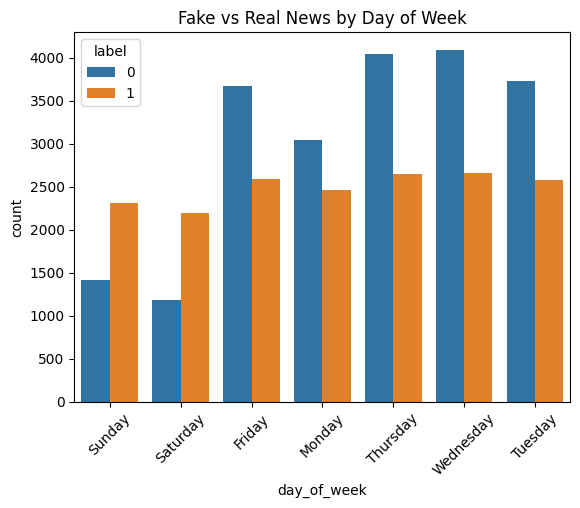

In [ ]:
df['day_of_week'] = df['date'].dt.day_name()

sns.countplot(data=df, x='day_of_week', hue='label')
plt.title("Fake vs Real News by Day of Week")
plt.xticks(rotation=45)
plt.show()


**Title Word Presense**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure titles are lowercase
df["title_lower"] = df["title"].str.lower()

# Sensational / biased keywords
keywords = {
    "trump": "trump",
    "breaking": "breaking",
    "shocking": "shocking",
    "alert": "alert",
    "scandal": "scandal",
    "exclusive": "exclusive",
    "crisis": "crisis",
    "leaked": "leaked",
    "fraud": "fraud",
    "bombshell": "bombshell"
}

# Create indicator columns for each keyword
for col, word in keywords.items():
    df[f"contains_{col}"] = df["title_lower"].str.contains(word, na=False).astype(int)

# Group by fake vs real and compute proportions
presence_table = df.groupby("news_type")[
    [f"contains_{k}" for k in keywords.keys()]
].mean().round(4) * 100  # convert to %

print("Title Word Presence (%):")
display(presence_table)


Title Word Presence (%):


,contains_trump,contains_breaking,contains_shocking,contains_alert,contains_scandal,contains_exclusive,contains_crisis,contains_leaked,contains_fraud,contains_bombshell
news_type,,,,,,,,,,
Fake,41.92,3.44,0.91,0.17,0.56,0.07,0.25,0.26,0.56,0.69
Real,25.91,0.04,0.02,0.03,0.24,0.99,1.09,0.03,0.25,0.00


<Figure size 1200x600 with 0 Axes>

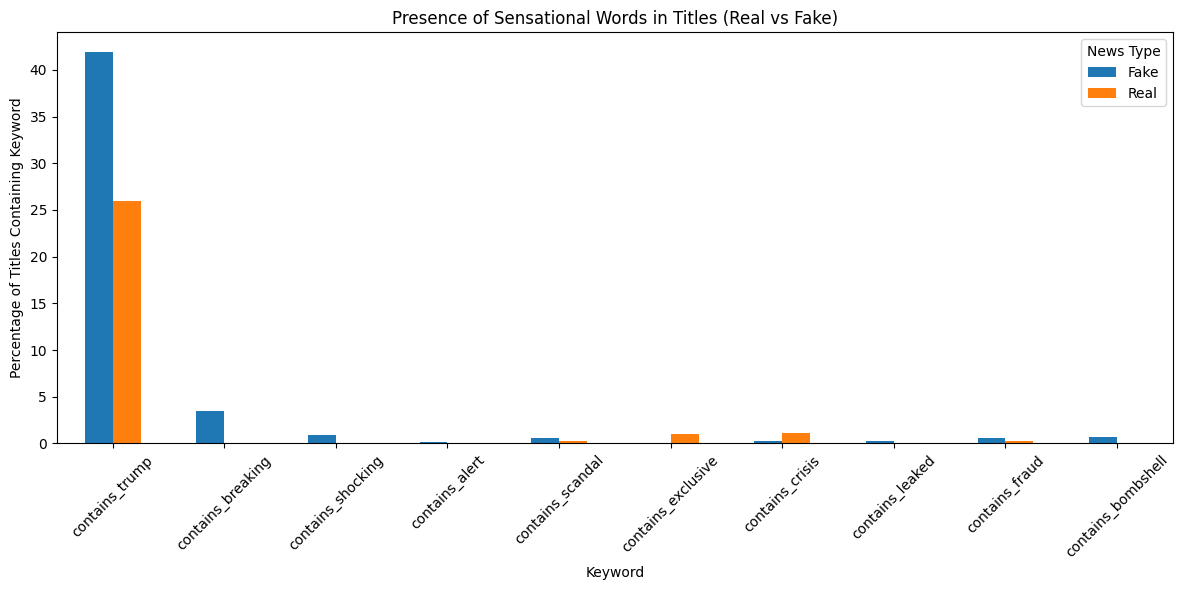

In [ ]:
plt.figure(figsize=(12,6))

presence_table.T.plot(kind="bar", figsize=(12,6))
plt.title("Presence of Sensational Words in Titles (Real vs Fake)")
plt.ylabel("Percentage of Titles Containing Keyword")
plt.xlabel("Keyword")
plt.xticks(rotation=45)
plt.legend(title="News Type")

plt.tight_layout()
plt.show()


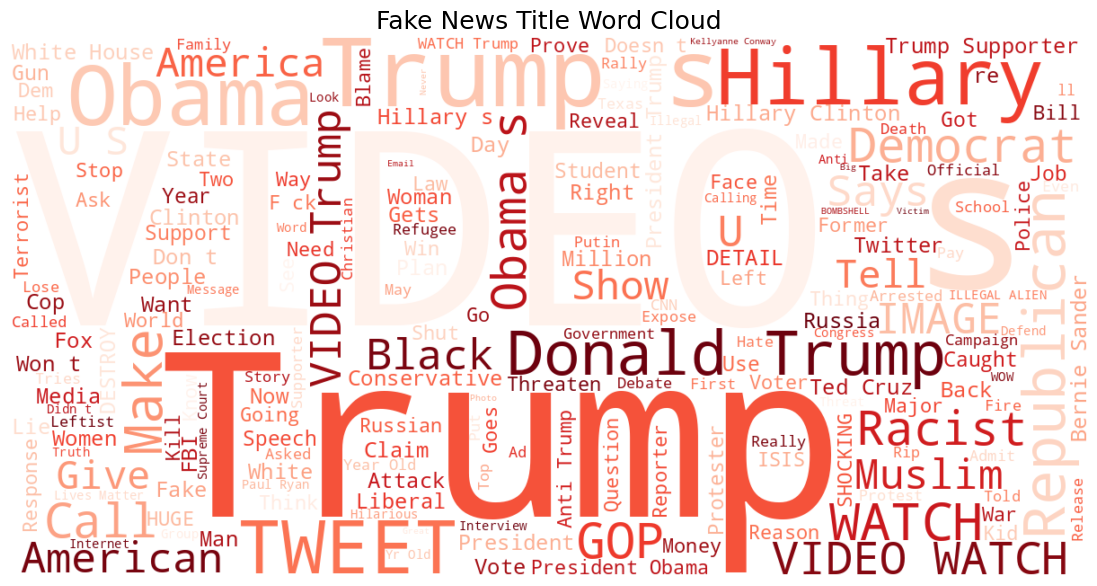

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Filter only fake news titles
fake_titles = df[df["label"] == 1]["title"].dropna().astype(str)

# Combine all titles into a single text
fake_text = " ".join(fake_titles)

# Optional: add more stopwords to remove common words
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "said", "will", "say", "one", "new",
    "news", "report", "reports", "breaking"
])

# Generate Word Cloud
wordcloud_fake = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Reds"
).generate(fake_text)

# Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Fake News Title Word Cloud", fontsize=18)
plt.show()


# Text representation and ML model


## TF-IDF
---



In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Prepare raw text and labels
X_raw = df['final_text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
y_labels = df['label']

# Split the data into training and testing sets before TF-IDF vectorization
# This ensures that the TF-IDF vectorizer learns its vocabulary and IDF values only from the training data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

tfidf_vectorizer = TfidfVectorizer()

# Fit the vectorizer ONLY on the training data, then transform both train and test
tfidf_dtm_train = tfidf_vectorizer.fit_transform(X_train_raw)
tfidf_dtm_test = tfidf_vectorizer.transform(X_test_raw)

# Step 1-2: Total TF-IDF score for each term across the entire training corpus.
# This ensures that the top terms are selected based on what the model is trained on.
tfidf_sum_scores_train = tfidf_dtm_train.sum(axis=0).A1

# Step 1-3: Get the indices of the top 30 terms from the training data
tfidf_top_30_indices = tfidf_sum_scores_train.argsort()[-30:][::-1]

# Step 1-4: Create the dataframes for X_train and X_test using only the top 30 terms
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
selected_feature_names = feature_names[tfidf_top_30_indices]

X_train = pd.DataFrame(tfidf_dtm_train[:, tfidf_top_30_indices].toarray(), columns=selected_feature_names)
X_test = pd.DataFrame(tfidf_dtm_test[:, tfidf_top_30_indices].toarray(), columns=selected_feature_names)

# Ensure y_train and y_test are Series for consistency
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
print("X_train (first 5 rows with top 30 TF-IDF terms):")
print(X_train.head())

X_train (first 5 rows with top 30 TF-IDF terms):
      trump      said     state  president  republican     would    people  \
0  0.066481  0.014381  0.009798   0.000000         0.0  0.027826  0.041435   
1  0.000000  0.056028  0.000000   0.048400         0.0  0.024091  0.000000   
2  0.148035  0.112079  0.000000   0.000000         0.0  0.048191  0.000000   
3  0.000000  0.000000  0.049933   0.000000         0.0  0.035453  0.118783   
4  0.192801  0.083412  0.028414   0.027021         0.0  0.000000  0.000000   

    clinton  house   reuters  ...  campaign      also   country  washington  \
0  0.000000    0.0  0.000000  ...       0.0  0.010477  0.012181         0.0   
1  0.000000    0.0  0.000000  ...       0.0  0.027211  0.000000         0.0   
2  0.000000    0.0  0.046922  ...       0.0  0.000000  0.063288         0.0   
3  0.020535    0.0  0.000000  ...       0.0  0.026697  0.031040         0.0   
4  0.000000    0.0  0.000000  ...       0.0  0.000000  0.000000         0.0   

   told

In [ ]:
# X_train, X_test, y_train, y_test are now prepared in the previous cell.
# This cell now only prints their shapes for verification.

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (30912, 30)
X_test shape: (7728, 30)
y_train shape: (30912,)
y_test shape: (7728,)


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the Logistic Regression model
LR = LogisticRegression(max_iter=100)
LR.fit(X_train, y_train)

# Making predictions using the Logistic Regression model
Y_LR = LR.predict(X_test)

# Evaluating model performance
accuracy_Y_LR = accuracy_score(y_test, Y_LR)
print("Logistic Regression Model Accuracy:", accuracy_Y_LR)

Logistic Regression Model Accuracy: 0.9325828157349897


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid_search = GridSearchCV(
    estimator=LR,
    param_grid=param_grid,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters for the Logistic Regression Model:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best Parameters for the Logistic Regression Model: {'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.9741522669620896


In [ ]:
# Train Logistic Regression model with best parameters from GridSearchCV
best_lr_model = grid_search.best_estimator_

Y_LR_tuned = best_lr_model.predict(X_test)

accuracy_Y_LR_tuned = accuracy_score(y_test, Y_LR_tuned)
print(f"Logistic Regression Model Accuracy with tuned hyperparameters: {accuracy_Y_LR_tuned}")

Logistic Regression Model Accuracy with tuned hyperparameters: 0.9703674948240165


### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier
IM = DecisionTreeClassifier()
IM.fit(X_train, y_train)

# Making predictions using the Decision Tree Classifier
Y_IM = IM.predict(X_test)

# Evaluating unpruned model performance
accuracy_Y_IM = accuracy_score(y_test, Y_IM)
print("Decision Tree Model Accuracy:", accuracy_Y_IM)

Decision Tree Model Accuracy: 0.9884834368530021


In [ ]:
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    estimator=IM,
    param_grid=param_grid_dt,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters for Decision Tree Classifier:", grid_search_dt.best_params_)
print("Best Cross-Validation Accuracy for Decision Tree Classifier:", grid_search_dt.best_score_)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best Parameters for Decision Tree Classifier: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation Accuracy for Decision Tree Classifier: 0.993174127783244


In [ ]:
# Train Decision Tree model with best parameters from GridSearchCV
best_dt_model = grid_search_dt.best_estimator_

Y_DT_tuned = best_dt_model.predict(X_test)

accuracy_Y_DT_tuned = accuracy_score(y_test, Y_DT_tuned)
print(f"Decision Tree Model Accuracy with tuned hyperparameters: {accuracy_Y_DT_tuned}")

Decision Tree Model Accuracy with tuned hyperparameters: 0.9921066252587992


### Support Vector Classifier

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM model
SVM = SVC(random_state=42)
SVM.fit(X_train, y_train)

# Making predictions using the SVM model
Y_SVM = SVM.predict(X_test)

# Evaluating model performance
accuracy_Y_SVM = accuracy_score(y_test, Y_SVM)
print("SVM Model Accuracy:", accuracy_Y_SVM)

SVM Model Accuracy: 0.9882246376811594


In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best 2-fold CV Accuracy:", grid_search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best 2-fold CV Accuracy: 0.9912654859515774


In [ ]:
# Train SVM model with best parameters from GridSearchCV
best_svm_model = grid_search.best_estimator_

Y_SVM_tuned = best_svm_model.predict(X_test)

accuracy_Y_SVM_tuned = accuracy_score(y_test, Y_SVM_tuned)
print(f"SVM Model Accuracy with tuned hyperparameters: {accuracy_Y_SVM_tuned}")

SVM Model Accuracy with tuned hyperparameters: 0.9882246376811594


### Evaluating the classification performance

In [ ]:
from sklearn.metrics import classification_report

# Building Classification Reports for 3 models
print("=== Classification Report: Tuned Logistic Regression ===")
print(classification_report(y_test, Y_LR_tuned))

print("=== Classification Report: Tuned Decision Tree Classifier ===")
print(classification_report(y_test, Y_DT_tuned))

print("=== Classification Report: Tuned Support Vector Classifier ===")
print(classification_report(y_test, Y_SVM_tuned))

=== Classification Report: Tuned Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4238
           1       0.97      0.97      0.97      3490

    accuracy                           0.97      7728
   macro avg       0.97      0.97      0.97      7728
weighted avg       0.97      0.97      0.97      7728

=== Classification Report: Tuned Decision Tree Classifier ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4238
           1       0.99      0.99      0.99      3490

    accuracy                           0.99      7728
   macro avg       0.99      0.99      0.99      7728
weighted avg       0.99      0.99      0.99      7728

=== Classification Report: Tuned Support Vector Classifier ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4238
           1       0.99      0.98      0.99      3490




## Sentence Transformer
---



In [ ]:
!pip install -q transformers datasets accelerate

In [ ]:
# ==== INSTALLS ====
!pip install -q sentence-transformers scikit-learn

# ==== IMPORTS ====
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# ==== CONFIG ====
TEXT_COL = "final_text"
LABEL_COL = "label"
N_SPLITS = 10  # 10-fold CV

# ==== LOAD & CLEAN TEXTS ====
texts = df[TEXT_COL].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
).fillna("").tolist()

y = df[LABEL_COL].values

# ==== EMBEDDINGS (FAST) ====
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X = embedder.encode(
    texts,
    batch_size=64,
    show_progress_bar=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/604 [00:00<?, ?it/s]

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 1. 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the Logistic Regression model
LR_2 = LogisticRegression(max_iter=100)
LR_2.fit(X_train, y_train)

# Making predictions using the Logistic Regression model
Y_LR_2 = LR_2.predict(X_test)

# Evaluating model performance
accuracy_Y_LR_2 = accuracy_score(y_test, Y_LR_2)
print("Logistic Regression Model Accuracy:", accuracy_Y_LR_2)

Logistic Regression Model Accuracy: 0.9557453416149069


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid_search = GridSearchCV(
    estimator=LR_2,
    param_grid=param_grid,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters for the Logistic Regression Model:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best Parameters for the Logistic Regression Model: {'C': 10, 'solver': 'saga'}
Best Cross-Validation Accuracy: 0.9669706902692496


In [ ]:
# Train Logistic Regression model with best parameters from GridSearchCV
best_lr_model_2 = grid_search.best_estimator_

Y_LR_tuned_2 = best_lr_model_2.predict(X_test)

accuracy_Y_LR_tuned_2 = accuracy_score(y_test, Y_LR_tuned_2)
print(f"Logistic Regression Model Accuracy with tuned hyperparameters: {accuracy_Y_LR_tuned_2}")

Logistic Regression Model Accuracy with tuned hyperparameters: 0.9658385093167702


### 2. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the Decision Tree Classifier
IM_2 = DecisionTreeClassifier()
IM_2.fit(X_train, y_train)

# Making predictions using the Decision Tree Classifier
Y_IM_2 = IM_2.predict(X_test)

# Evaluating unpruned model performance
accuracy_Y_IM_2 = accuracy_score(y_test, Y_IM_2)
print("Decision Tree Model Accuracy:", accuracy_Y_IM_2)

Decision Tree Model Accuracy: 0.8110766045548654


In [ ]:
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    estimator=IM_2,
    param_grid=param_grid_dt,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters for Decision Tree Classifier:", grid_search_dt.best_params_)
print("Best Cross-Validation Accuracy for Decision Tree Classifier:", grid_search_dt.best_score_)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best Parameters for Decision Tree Classifier: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy for Decision Tree Classifier: 0.8329775486399399


In [ ]:
# Train Decision Tree model with best parameters from GridSearchCV
best_dt_model = grid_search_dt.best_estimator_

Y_DT_tuned_2 = best_dt_model.predict(X_test)

accuracy_Y_DT_tuned_2 = accuracy_score(y_test, Y_DT_tuned)
print(f"Decision Tree Model Accuracy with tuned hyperparameters: {accuracy_Y_DT_tuned_2}")

In [ ]:
## COMPUTATIONALLY FEASIBLE ALTERNATIVE TO GRIDSEARCH ##

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# ----------------------------
# Parameter distributions
# ----------------------------
param_dist = {
    "max_depth": randint(5, 40),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "criterion": ["gini", "entropy", "log_loss"]
}

# ----------------------------
# Randomized Search
# ----------------------------

random_search_dt = RandomizedSearchCV(
    estimator=IM_2,
    param_distributions=param_dist,
    n_iter=50,                 # adjust if needed
    scoring="accuracy",        # or "f1_macro" for imbalance
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_dt.fit(X_train, y_train)


RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(max_depth=20,
                                                    min_samples_leaf=10,
                                                    min_samples_split=20,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eb41b0ffbc0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eb410bb6e40>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7eb388822ba0>},
                   random_state=42, scoring='accuracy')

In [ ]:
# ----------------------------
# Best model & evaluation
# ----------------------------
best_dt_model = random_search_dt.best_estimator_

Y_DT_tuned = best_dt_model.predict(X_test)
accuracy_Y_DT_tuned = accuracy_score(y_test, Y_DT_tuned)

print("Best DT parameters:", random_search_dt.best_params_)
print("Tuned Decision Tree Accuracy:", accuracy_Y_DT_tuned)

Best DT parameters: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 15, 'min_samples_split': 4}
Tuned Decision Tree Accuracy: 0.8249223602484472


In [ ]:
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    estimator=IM_2,
    param_grid=param_grid_dt,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Best Parameters for Decision Tree Classifier:", grid_search_dt.best_params_)
print("Best Cross-Validation Accuracy for Decision Tree Classifier:", grid_search_dt.best_score_)

In [ ]:
from sklearn.metrics import classification_report



print("=== Classification Report: Tuned Decision Tree Classifier ===")
print(classification_report(y_test, Y_DT_tuned))



=== Classification Report: Tuned Decision Tree Classifier ===
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      4238
           1       0.82      0.79      0.80      3490

    accuracy                           0.82      7728
   macro avg       0.82      0.82      0.82      7728
weighted avg       0.82      0.82      0.82      7728



### 3. Support Vector Machine

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM model
SVM_2 = SVC(random_state=42)
SVM_2.fit(X_train, y_train)

# Making predictions using the SVM model
Y_SVM_2 = SVM_2.predict(X_test)

# Evaluating model performance
accuracy_Y_SVM_2 = accuracy_score(y_test, Y_SVM_2)
print("SVM Model Accuracy:", accuracy_Y_SVM_2)

SVM Model Accuracy: 0.9743788819875776


In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best 10-fold CV Accuracy:", grid_search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best 10-fold CV Accuracy: 0.9808811983043038


In [ ]:
# Train SVM model with best parameters from GridSearchCV
best_svm_model_2 = grid_search.best_estimator_

Y_SVM_tuned_2 = best_svm_model_2.predict(X_test)

accuracy_Y_SVM_tuned_2 = accuracy_score(y_test, Y_SVM_tuned_2)
print(f"SVM Model Accuracy with tuned hyperparameters: {accuracy_Y_SVM_tuned_2}")

SVM Model Accuracy with tuned hyperparameters: 0.9787784679089027


In [ ]:
from sklearn.metrics import classification_report

# Building Classification Reports for 3 models
print("=== Classification Report: Tuned Logistic Regression ===")
print(classification_report(y_test, Y_LR_tuned_2))

print("=== Classification Report: Tuned Decision Tree Classifier ===")
print(classification_report(y_test, Y_DT_tuned_2))

print("=== Classification Report: Tuned Support Vector Classifier ===")
print(classification_report(y_test, Y_SVM_tuned_2))

# Sentiment Analysis

In [ ]:
sentiment_features = df[["compound_text"]].values

# Combine embeddings + sentiment features
X_enriched = np.hstack([X, sentiment_features])

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, f1_score

# 1. 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_enriched, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Grid definition
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

scorer = make_scorer(f1_score, average="macro")

# 3. GridSearch on TRAIN ONLY
svm = LinearSVC()

grid_search = GridSearchCV(
    svm,
    param_grid,
    scoring=scorer,
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)

# 4. Evaluate best model on TEST SET
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

print("\n=== Classification Report on 20% Test Set ===")
print(classification_report(y_test, y_pred))

Fitting 10 folds for each of 5 candidates, totalling 50 fits
Best parameters found: {'C': 10}

=== Classification Report on 20% Test Set ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4238
           1       0.97      0.96      0.96      3490

    accuracy                           0.97      7728
   macro avg       0.97      0.96      0.97      7728
weighted avg       0.97      0.97      0.97      7728



# **Sentiment Scores**

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# Apply VADER to titles
df["sentiment"] = df["title"].astype(str).apply(lambda x: sia.polarity_scores(x))

# Extract individual scores into columns
df["compound"] = df["sentiment"].apply(lambda x: x["compound"])
df["pos"] = df["sentiment"].apply(lambda x: x["pos"])
df["neg"] = df["sentiment"].apply(lambda x: x["neg"])
df["neu"] = df["sentiment"].apply(lambda x: x["neu"])


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
sentiment_summary = df.groupby("news_type")[["compound","pos","neg","neu"]].mean().reset_index()
sentiment_summary


,news_type,compound,pos,neg,neu
0,Fake,-0.164718,0.084016,0.158754,0.757231
1,Real,-0.066811,0.079671,0.118044,0.802286


/tmp/ipython-input-3956564023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_summary, x="news_type", y="compound", palette=["#4A90E2","#D0021B"])


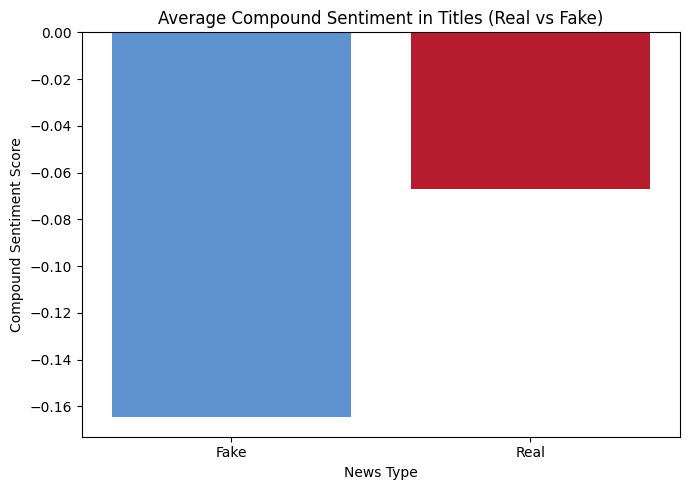

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.barplot(data=sentiment_summary, x="news_type", y="compound", palette=["#4A90E2","#D0021B"])

plt.title("Average Compound Sentiment in Titles (Real vs Fake)")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("News Type")
plt.tight_layout()
plt.show()


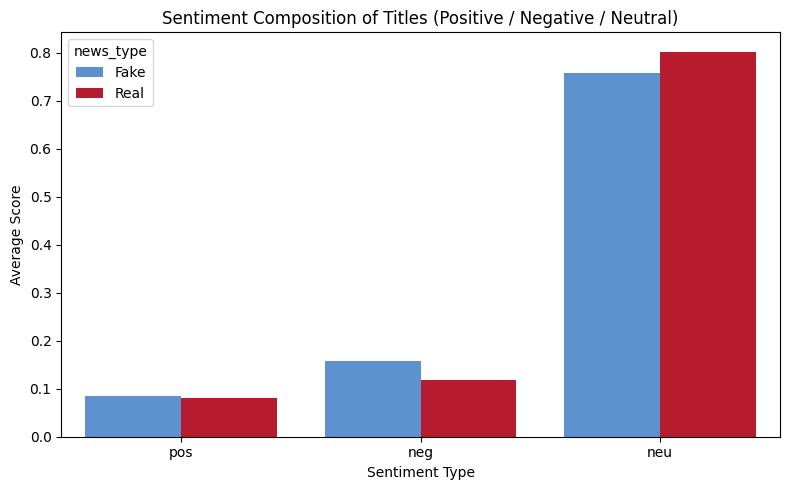

In [ ]:
sentiment_melted = df.groupby("news_type")[["pos","neg","neu"]].mean().reset_index().melt(id_vars="news_type")

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_melted, x="variable", y="value", hue="news_type",
            palette=["#4A90E2","#D0021B"])

plt.title("Sentiment Composition of Titles (Positive / Negative / Neutral)")
plt.xlabel("Sentiment Type")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()


In [ ]:
# Apply VADER to text
df["sentiment_text"] = df["final_text"].astype(str).apply(lambda x: sia.polarity_scores(x))

# Extract individual scores into columns
df["compound_text"] = df["sentiment_text"].apply(lambda x: x["compound"])
df["pos_text"] = df["sentiment_text"].apply(lambda x: x["pos"])
df["neg_text"] = df["sentiment_text"].apply(lambda x: x["neg"])
df["neu_text"] = df["sentiment_text"].apply(lambda x: x["neu"])

In [ ]:
sentiment_summary = df.groupby("news_type")[["compound_text","pos_text","neg_text","neu_text"]].mean().reset_index()
sentiment_summary

,news_type,compound_text,pos_text,neg_text,neu_text
0,Fake,-0.050209,0.147386,0.145215,0.707227
1,Real,0.099117,0.127024,0.113241,0.759735


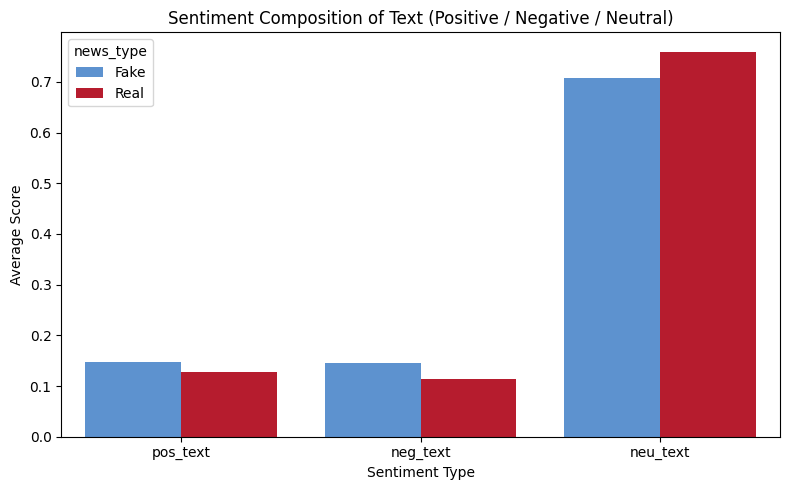

In [ ]:
sentiment_comb = df.groupby("news_type")[["pos_text","neg_text","neu_text"]].mean().reset_index().melt(id_vars="news_type")

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_comb, x="variable", y="value", hue="news_type",
            palette=["#4A90E2","#D0021B"])

plt.title("Sentiment Composition of Text (Positive / Negative / Neutral)")
plt.xlabel("Sentiment Type")
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()